In [73]:
import sys
import time
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm);

In [136]:
class Net(nn.Module):
    def __init__(self, input_size=2, hidden_size=128):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x):
        x = self.net(x)
        return x
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# Collocation points — meshgrid of t and r
t_1d = torch.linspace(0, 1, 100)
r_1d = torch.linspace(0, 1, 100)
T, R = torch.meshgrid(t_1d, r_1d, indexing='ij')  # each (100, 100)
T = T.reshape(-1, 1).requires_grad_(True)          # (10000, 1)
R = R.reshape(-1, 1).requires_grad_(True)          # (10000, 1)
TR = torch.cat([T, R], dim=1)                      # (10000, 2)

def grad(outputs, inputs):
    """Computes the partial derivative of 
    an output with respect to an input.
    Args:
        outputs: (N, 1) tensor
        inputs: (N, D) tensor
    """
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )[0]

def ic_loss(model):
    # Initial condition u(r, 0) = c0
    c0 = 1.0
    r_ic = torch.linspace(0, 1, 100).reshape(-1, 1)
    t_ic = torch.zeros(100, 1)
    
    tr_ic = torch.cat([t_ic, r_ic], dim=1)
    u_ic = model(tr_ic)
    return torch.mean((u_ic - c0)**2)

def bc_loss(model):
    # Boundary condition du/dr|_{r=0} = 0
    t_bc = torch.linspace(0, 1, 100).reshape(-1, 1)  # (100, 1)

    r0 = torch.zeros(100, 1).requires_grad_(True)  # r=0 boundary
    u_r0 = model(torch.cat([t_bc, r0], dim=1))
    du_dr0 = grad(u_r0, r0)
    return torch.mean(du_dr0**2)

def physics_loss(y_pred, T, R):
    # compute du/dt du/dr
    du_dt = grad(y_pred, T)
    du_dr = grad(y_pred, R)
    d2u_dr2 = grad(du_dr, R)

    # ODE residual for du/dt + u = 0
    ode = du_dt + y_pred
    # PDE du/dt - D / r^2 * d/dr[r^2 * du/dr] = 0
    # Expanded: du/dt - D  * (2 / r * du/dr + d^2u/dr^2) = 0
    D = 0.1
    pde = du_dt - D * (2 / (R + 1e-8) * du_dr + d2u_dr2)
    return torch.mean(pde**2)

In [137]:
def training(epochs=50, tol=2.5e-4, model=model, optimizer=optimizer):
    history = {'loss': []}
    model.train()
    
    for epoch in range(epochs):
        y_pred = model(TR)

        p_loss = physics_loss(y_pred, T, R)
        i_loss = ic_loss(model)
        b_loss = bc_loss(model)

        loss = p_loss + i_loss + b_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history['loss'].append(p_loss.item())

        if epoch % 100 == 0:
            print(f'Epoch {epoch+1} loss: {p_loss:.5f}')

    return model, history

In [138]:
model, history = training(epochs=500, model=model, optimizer=optimizer)

Epoch 1 loss: 3903827456.00000
Epoch 101 loss: 2054451840.00000
Epoch 201 loss: 151542560.00000
Epoch 301 loss: 183996992.00000
Epoch 401 loss: 19149036.00000


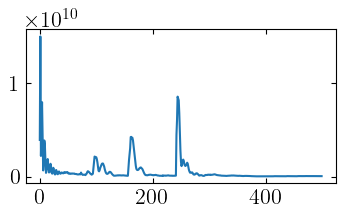

In [139]:
plt.figure(figsize=(4,2))
plt.plot(history['loss'])

(100, 100)


/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_22563/1035200694.py:7: UserWarning: The following kwargs were not used by contour: 'level'
  plt.contourf(T_plot, R_plot, pred, level=100, cmap='Blues')


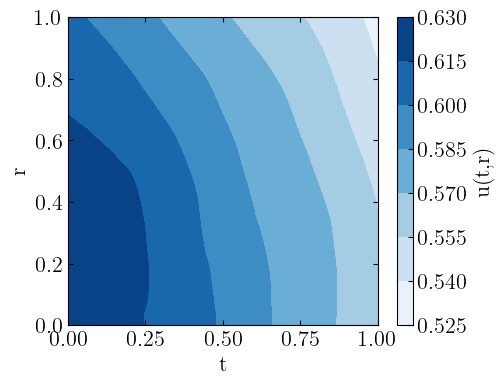

In [141]:
pred = model(TR).detach().numpy().reshape(100, 100) # Shape (100, 100) = (t_index, r_index)
print(pred.shape)
T_plot = T.detach().numpy().reshape(100, 100)
R_plot = R.detach().numpy().reshape(100, 100)

plt.figure(figsize=(5,4))
plt.contourf(T_plot, R_plot, pred, level=100, cmap='Blues')
plt.xlabel('t')
plt.ylabel('r')
plt.colorbar(label='u(t,r)')

# t_vals = t_1d.numpy()
# r_vals = r_1d.numpy()

# # Plot u vs t for fixed r values
# plt.figure(figsize=(6, 3))
# for r_idx in [0, 25, 50, 75, 99]:
#     plt.plot(t_vals, pred[:, r_idx], label=f'r={r_vals[r_idx]:.2f}')
# plt.xlabel('t')
# plt.ylabel('u(t, r)')
# plt.legend()
# plt.title('u vs t for fixed r')